In [1]:
# Importing required libraries
import requests
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import json

c:\Users\RONIT\Desktop\Projects\Terra_Forecast\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
# Loading country coordinates
with open("../data/country_coordinates.json") as f:
    country_coordinates = json.load(f)

lat, lon = country_coordinates["Nepal"]

In [3]:
# Pulling 5 years of daily historical temperature data for Nepal
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2019-01-01",
    "end_date": "2023-12-31",
    "daily": "temperature_2m_mean",
    "timezone": "auto"
}

response = requests.get(url, params=params)
weather_data = response.json()

df = pd.DataFrame({
    "date": weather_data["daily"]["time"],
    "temperature": weather_data["daily"]["temperature_2m_mean"]
})
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,temperature
0,2019-01-01,3.5
1,2019-01-02,1.4
2,2019-01-03,0.3
3,2019-01-04,2.0
4,2019-01-05,2.4


In [4]:
df

,date,temperature
0,2019-01-01,3.5
1,2019-01-02,1.4
2,2019-01-03,0.3
3,2019-01-04,2.0
4,2019-01-05,2.4
...,...,...
1821,2023-12-27,5.8
1822,2023-12-28,4.7
1823,2023-12-29,3.7
1824,2023-12-30,4.5


In [5]:
# Preparing the data in Prophet's required format
season_data = df.rename(columns={"date": "ds", "temperature": "y"})

# This time, we WANT yearly seasonality — that's the whole point, unlike our trend model earlier
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(season_data)

11:26:40 - cmdstanpy - INFO - Chain [1] start processing
11:26:41 - cmdstanpy - INFO - Chain [1] done processing


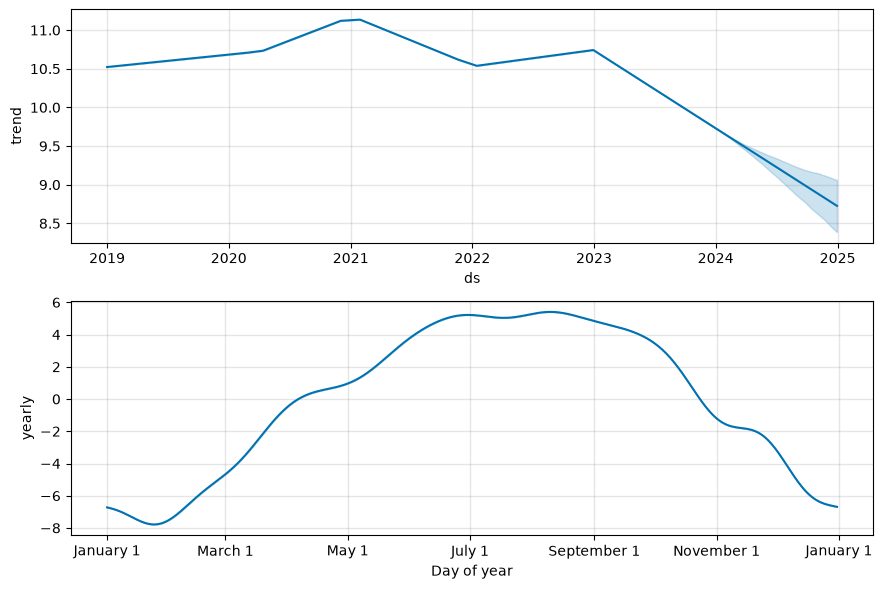

In [6]:
# Generating a forecast that includes the seasonal component
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

# Plotting the components — this separates trend from the yearly seasonal pattern
fig = model.plot_components(forecast)
plt.show()

In [7]:
# Extracting the day-of-year with the highest and lowest seasonal values (peak summer, peak winter)
yearly_component = forecast[["ds", "yearly"]].copy()
yearly_component["day_of_year"] = yearly_component["ds"].dt.dayofyear

# Averaging across all years for each day-of-year to get one clean seasonal curve
seasonal_curve = yearly_component.groupby("day_of_year")["yearly"].mean()

peak_day = seasonal_curve.idxmax()
trough_day = seasonal_curve.idxmin()

# Converting day-of-year back into an actual readable date
import datetime
peak_date = datetime.datetime(2024, 1, 1) + datetime.timedelta(days=int(peak_day) - 1)
trough_date = datetime.datetime(2024, 1, 1) + datetime.timedelta(days=int(trough_day) - 1)

print("Warmest point of the year (approx):", peak_date.strftime("%B %d"))
print("Coldest point of the year (approx):", trough_date.strftime("%B %d"))

Warmest point of the year (approx): August 10
Coldest point of the year (approx): January 25


In [8]:
# A complete, reusable function: given a country's coordinates, return its seasonal peak/trough dates
def get_seasonal_pattern(lat, lon, start_date="2019-01-01", end_date="2023-12-31"):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "auto"
    }
    response = requests.get(url, params=params)
    weather_data = response.json()

    df = pd.DataFrame({
        "date": weather_data["daily"]["time"],
        "temperature": weather_data["daily"]["temperature_2m_mean"]
    })
    df["date"] = pd.to_datetime(df["date"])
    season_data = df.rename(columns={"date": "ds", "temperature": "y"})

    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(season_data)

    future = model.make_future_dataframe(periods=365)
    forecast = model.predict(future)

    yearly_component = forecast[["ds", "yearly"]].copy()
    yearly_component["day_of_year"] = yearly_component["ds"].dt.dayofyear
    seasonal_curve = yearly_component.groupby("day_of_year")["yearly"].mean()

    peak_day = seasonal_curve.idxmax()
    trough_day = seasonal_curve.idxmin()

    peak_date = datetime.datetime(2024, 1, 1) + datetime.timedelta(days=int(peak_day) - 1)
    trough_date = datetime.datetime(2024, 1, 1) + datetime.timedelta(days=int(trough_day) - 1)

    return {
        "warmest_point": peak_date.strftime("%B %d"),
        "coldest_point": trough_date.strftime("%B %d")
    }

In [9]:
# Testing on a Southern Hemisphere country — seasons should be reversed compared to Nepal
lat, lon = country_coordinates["Australia"]
print(get_seasonal_pattern(lat, lon))

11:34:04 - cmdstanpy - INFO - Chain [1] start processing
11:34:04 - cmdstanpy - INFO - Chain [1] done processing


{'warmest_point': 'January 10', 'coldest_point': 'June 30'}


In [10]:
# Simple rule-based disaster risk assessment using live weather data
def assess_disaster_risk(weather_info):
    risk_flags = []

    if weather_info["windspeed"] > 60:
        risk_flags.append("High wind risk (possible storm/hurricane conditions)")

    if weather_info["condition"] in ["Heavy rain", "Violent rain showers", "Thunderstorm with heavy hail"]:
        risk_flags.append("Heavy rainfall risk (possible flooding)")

    if not risk_flags:
        risk_flags.append("No significant weather-based risk detected")

    return risk_flags

# Testing it with Nepal's current weather
import sys
sys.path.append("../src/api")
from weather_client import get_current_weather

current = get_current_weather(lat, lon)
print(assess_disaster_risk(current))

['No significant weather-based risk detected']


In [11]:
# Testing the module version
import sys
sys.path.append("../src/disaster")
from risk_rules import assess_disaster_risk

print(assess_disaster_risk(current))

['No significant weather-based risk detected']
